In [21]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt

In [22]:
mdb_path = r"C:\Users\Jouke\Desktop\emergo_dataset\DemoDataBetsyBike.mdb"

conn_str = (
    r"Driver={Microsoft Access Driver (*.mdb, *.accdb)};"
    fr"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

C:\Users\Jouke\AppData\Local\Temp\ipykernel_15828\3883999326.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  t.table_name: pd.read_sql(f"SELECT * FROM [{t.table_name}]", conn)


Aantal regels: 119,108
Totaalomzet: €109,795,540.77
Beschikbare jaren: [np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009)]


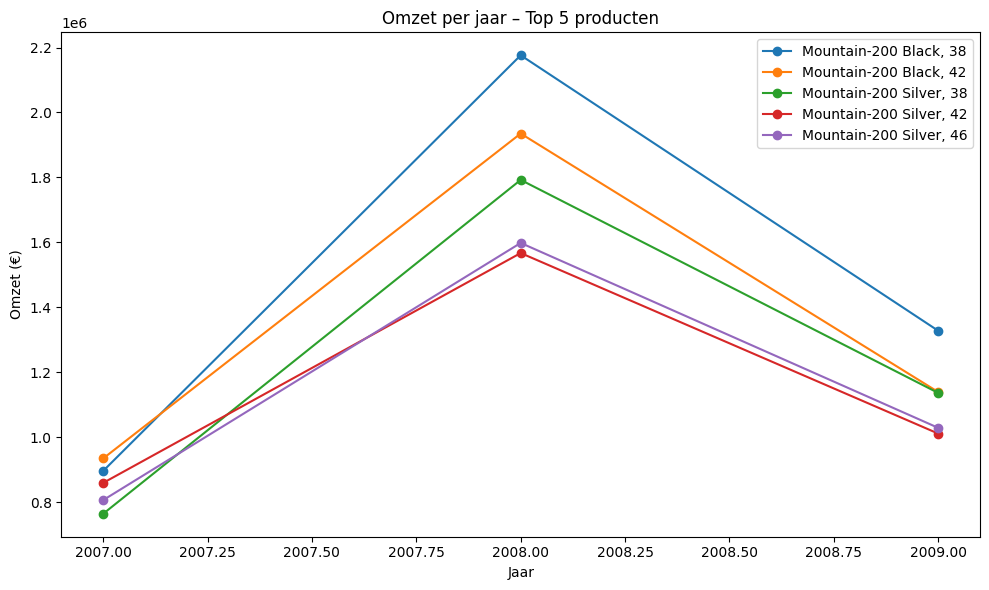

,ProductID,ProductName,Category,Year,Revenue,YoY_Growth
194,782.0,"Mountain-200 Black, 38",Bikes,2007,896511.60,NaN
195,782.0,"Mountain-200 Black, 38",Bikes,2008,2176123.80,1.427
196,782.0,"Mountain-200 Black, 38",Bikes,2009,1327957.41,-0.390
197,783.0,"Mountain-200 Black, 42",Bikes,2007,934918.05,NaN
198,783.0,"Mountain-200 Black, 42",Bikes,2008,1935147.23,1.070
199,783.0,"Mountain-200 Black, 42",Bikes,2009,1139429.49,-0.411
185,779.0,"Mountain-200 Silver, 38",Bikes,2007,764614.02,NaN
186,779.0,"Mountain-200 Silver, 38",Bikes,2008,1792441.51,1.344
187,779.0,"Mountain-200 Silver, 38",Bikes,2009,1136622.49,-0.366
188,780.0,"Mountain-200 Silver, 42",Bikes,2007,859725.33,NaN


In [23]:
# --- 3️⃣ Lees tabellen in ---
dfs = {
    t.table_name: pd.read_sql(f"SELECT * FROM [{t.table_name}]", conn)
    for t in conn.cursor().tables(tableType='TABLE')
}
conn.close()

# --- 4️⃣ Laad relevante tabellen ---
df_sales = dfs['SalesOrderDetail'].copy()
df_header = dfs['SalesOrderHeader'].copy()
df_product = dfs['Product'].copy()
df_subcat = dfs['ProductSubcategory'].copy()
df_category = dfs['ProductCategory'].copy()

# --- 5️⃣ Bereken omzet per orderregel (Revenue) ---
df_sales['Revenue'] = (
    df_sales['OrderQty'].astype(float)
    * df_sales['UnitPrice'].astype(float)
    * (1 - df_sales['UnitPriceDiscount'].astype(float))
)

# --- 6️⃣ Maak dimensies uniek ---
product_dim = (
    df_product[['ProductID', 'Name', 'ProductSubcategoryID']]
    .drop_duplicates(subset=['ProductID'])
    .rename(columns={'Name': 'ProductName'})
)
subcat_dim = df_subcat[['ProductSubcategoryID', 'ProductCategoryID']].drop_duplicates()
category_dim = (
    df_category[['ProductCategoryID', 'Name']]
    .drop_duplicates(subset=['ProductCategoryID'])
    .rename(columns={'Name': 'Category'})
)

# --- 7️⃣ Combineer alles in één tabel ---
sales_full = (
    df_sales
    .merge(df_header[['SalesOrderID', 'OrderDate']], on='SalesOrderID', how='left', validate='m:1')
    .merge(product_dim, on='ProductID', how='left', validate='m:1')
    .merge(subcat_dim, on='ProductSubcategoryID', how='left', validate='m:1')
    .merge(category_dim, on='ProductCategoryID', how='left', validate='m:1')
)

# --- 8️⃣ Controle & omzet-sanity check ---
print(f"Aantal regels: {len(sales_full):,}")
print(f"Totaalomzet: €{sales_full['Revenue'].sum():,.2f}")

# --- 9️⃣ Voeg jaarkolom toe ---
sales_full['OrderDate'] = pd.to_datetime(sales_full['OrderDate'], errors='coerce')
sales_full['Year'] = sales_full['OrderDate'].dt.year
print("Beschikbare jaren:", sorted(sales_full['Year'].dropna().unique()))

# --- 🔟 Bereken omzet per product per jaar ---
product_yearly = (
    sales_full
    .groupby(['ProductID', 'ProductName', 'Category', 'Year'], as_index=False)['Revenue']
    .sum()
    .sort_values(['ProductName', 'Year'])
)

# --- 11️⃣ Bereken Year-over-Year (YoY) groei ---
product_yearly['YoY_Growth'] = (
    product_yearly
    .groupby('ProductID')['Revenue']
    .pct_change()
)

# --- 12️⃣ Selecteer Top X producten op totale omzet ---
top_x = 5
top_products = (
    sales_full
    .groupby(['ProductID', 'ProductName'], as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
    .head(top_x)
)

# --- 13️⃣ Filter deze producten voor YoY-analyse ---
top_products_yoy = product_yearly[product_yearly['ProductID'].isin(top_products['ProductID'])]

# --- 14️⃣ Visualiseer omzettrend per jaar ---
plt.figure(figsize=(10,6))
for name, group in top_products_yoy.groupby('ProductName'):
    plt.plot(group['Year'], group['Revenue'], marker='o', label=name)

plt.title(f"Omzet per jaar – Top {top_x} producten")
plt.xlabel("Jaar")
plt.ylabel("Omzet (€)")
plt.legend()
plt.tight_layout()
plt.show()

# --- 15️⃣ Toon tabel met YoY-groei ---
display(
    top_products_yoy
    .sort_values(['ProductName', 'Year'])
    .round({'Revenue': 2, 'YoY_Growth': 3})
)

In [24]:
print("Aantal unieke sales-jaren:", sales_full['Year'].nunique())
print("Sales-jaren:", sorted(sales_full['Year'].dropna().unique()))


Aantal unieke sales-jaren: 4
Sales-jaren: [np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009)]


Totale omzet per jaar:


,Year,Revenue,YoY_Growth
0,2006,11331808.96,NaN
1,2007,30674773.17,1.707
2,2008,42011037.16,0.370
3,2009,25777921.47,-0.386


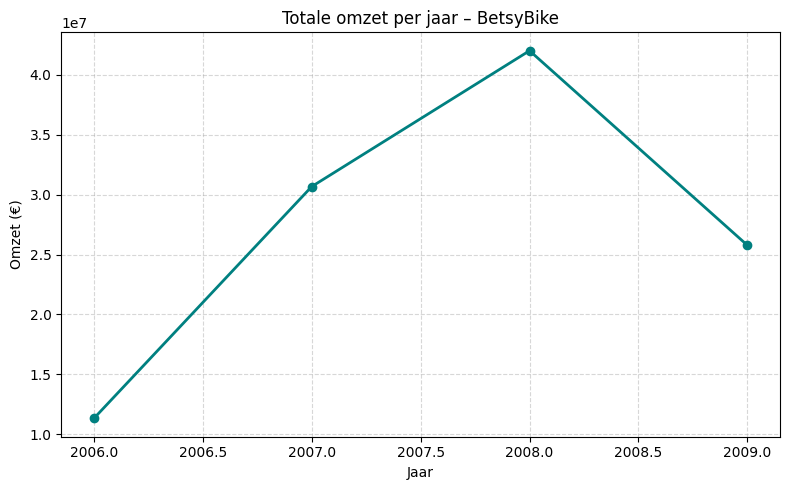

In [25]:
# ======================================
# Totale omzet per jaar – BetsyBike overzicht
# ======================================

# --- 1️⃣ Bereken totale omzet per jaar ---
total_sales_per_year = (
    sales_full.groupby('Year', as_index=False)['Revenue']
    .sum()
    .sort_values('Year')
)

# --- 2️⃣ Bereken jaar-op-jaar groei ---
total_sales_per_year['YoY_Growth'] = total_sales_per_year['Revenue'].pct_change()

# --- 3️⃣ Toon resultaten ---
print("Totale omzet per jaar:")
display(total_sales_per_year.round({'Revenue': 2, 'YoY_Growth': 3}))

# --- 4️⃣ Visualisatie ---
plt.figure(figsize=(8,5))
plt.plot(total_sales_per_year['Year'], total_sales_per_year['Revenue'], marker='o', color='teal', linewidth=2)
plt.title("Totale omzet per jaar – BetsyBike")
plt.xlabel("Jaar")
plt.ylabel("Omzet (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
